(2,)
(x^(0),y^(0))=(1.0,300.0)


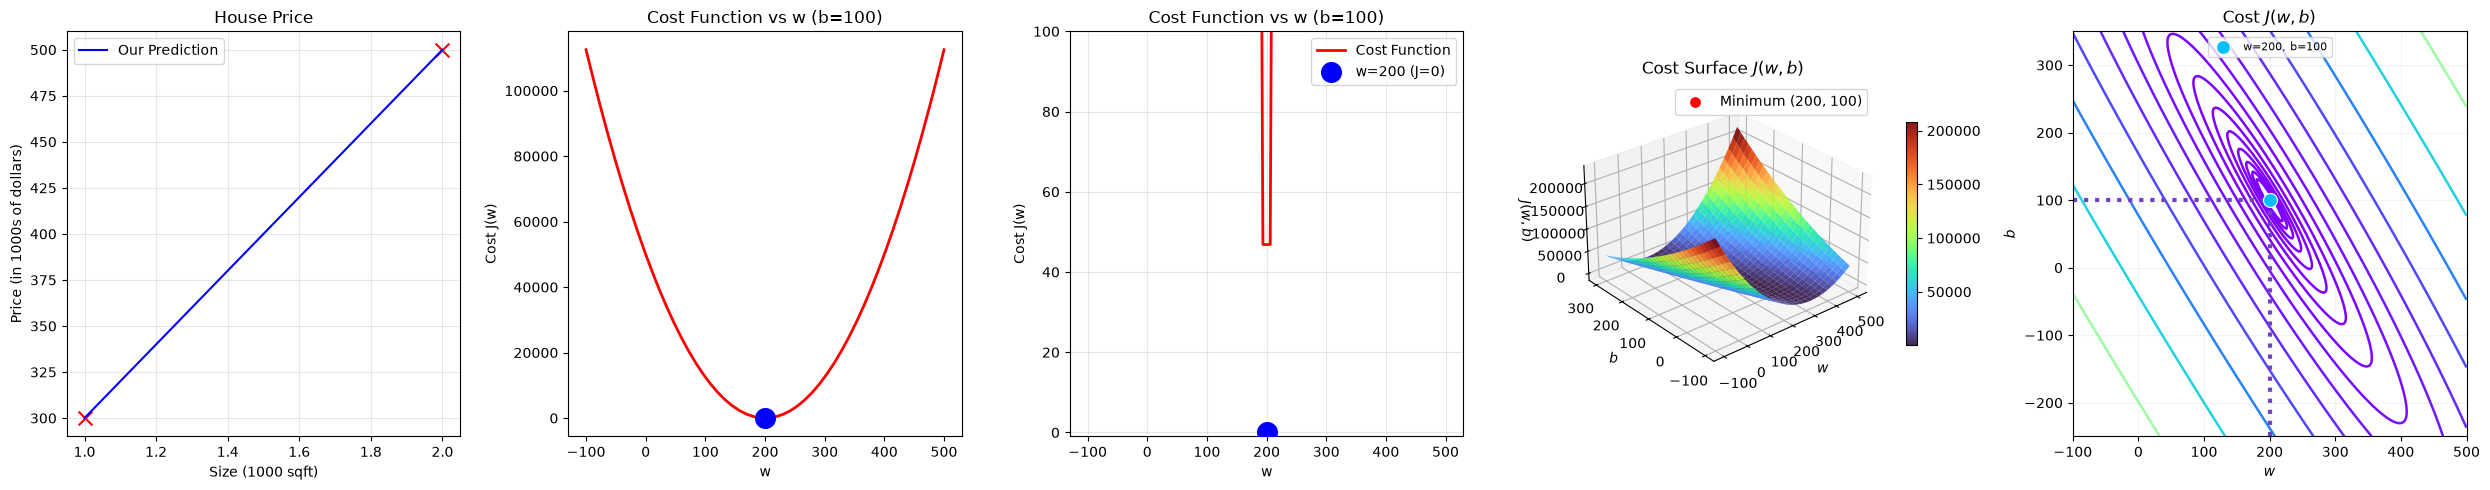

In [47]:
import numpy as np
import matplotlib.pyplot as plt
x_train=np.array([1.0,2.0])
y_train=np.array([300.0,500.0])
print(x_train.shape)
m=x_train.shape[0]
i=0
x_i=x_train[i]
y_i=y_train[i]
print(f"(x^({i}),y^({i}))=({x_train[i]},{y_train[i]})")
# plt.scatter(x_train,y_train,marker='x',c='r')
# plt.title("House Price")
# plt.xlabel("Size (1000 sqft)")
# plt.ylabel("Price(in 1000s of dollars)")
# plt.show()
def model_output(x,w,b):
    m=x.shape[0]
    f_wb=np.zeros(m)    #初识化一个大小与传入值一样的数组
    for i in range(m):
        f_wb[i]=w*x[i]+b
    return f_wb
def cost_function(x,y,w,b):
    m=x.shape[0]
    cost=0
    for i in range(m):
        f_wb=w*x[i]+b
        cost_sum=(y[i]-f_wb)**2
        cost+=cost_sum
    return cost/(2*m)

w_value = np.linspace(-100, 500, 50)
cost_value=[]
for w in w_value:
    result=cost_function(x_train,y_train,w,100)
    cost_value.append(result)
    
w_vals = np.linspace(-100, 500, 30)
b_vals = np.linspace(-100, 300, 30)
W, B = np.meshgrid(w_vals, b_vals)
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = cost_function(x_train, y_train, W[i, j], B[i, j])

w_contour = np.linspace(-100, 500, 200)
b_contour = np.linspace(-250, 350, 200)
W_contour, B_contour = np.meshgrid(w_contour, b_contour)
prediction_contour = (W_contour[..., np.newaxis] * x_train+ B_contour[..., np.newaxis])
J_contour = np.mean((prediction_contour - y_train) ** 2,axis=2)/2

tmp_model_output=model_output(x_train,200,100)
plt.figure(figsize=(25, 5))  # 设置总画布大小

# ---- 左图：拟合直线 ----
plt.subplot(1, 5, 1)
plt.plot(x_train, tmp_model_output, c='b', label="Our Prediction")
plt.scatter(x_train, y_train, marker='x', c='r', s=100)
plt.title("House Price")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (in 1000s of dollars)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,5,2)
plt.plot(w_value,cost_value, c='r', linewidth=2, label="Cost Function")
plt.scatter([200], [cost_function(x_train, y_train, 200, 100)], 
            color='blue', s=200, zorder=5, label="w=200 (J=0)")
plt.title("Cost Function vs w (b=100)")
plt.xlabel("w")
plt.ylabel("Cost J(w)")

plt.subplot(1, 5, 3)
plt.plot(w_value, cost_value, c='r', linewidth=2, label="Cost Function")
plt.scatter([200], [cost_function(x_train, y_train, 200, 100)], 
            color='blue', s=200, zorder=5, label="w=200 (J=0)")
plt.title("Cost Function vs w (b=100)")
plt.xlabel("w")
plt.ylabel("Cost J(w)")
plt.ylim(-1, 100)
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.subplot(1, 5, 4, projection='3d')
surface = ax.plot_surface(
    W, B, J_vals,
    cmap='turbo',
    edgecolor='none',
    antialiased=True,
    alpha=0.9
)
ax.scatter(200, 100, 0, color='red', s=45, label='Minimum (200, 100)')
ax.set_title(r'Cost Surface $J(w, b)$')
ax.set_xlabel(r'$w$')
ax.set_ylabel(r'$b$')
ax.set_zlabel(r'$J(w, b)$')
ax.view_init(elev=28, azim=-130)  # 调整观察角度
ax.set_box_aspect((1, 1, 0.65))
ax.legend()
plt.colorbar(surface, ax=ax, shrink=0.55, pad=0.08)

ax5=plt.subplot(1,5,5)
levels = np.geomspace(50,J_contour.max(),16)
contours = ax5.contour(
    W_contour,
    B_contour,
    J_contour,
    levels=levels,
    cmap='rainbow',
    linewidths=1.8
)
# 参考图中选择的参数点
selected_w = 200
selected_b = 100
ax5.scatter(
    selected_w,
    selected_b,
    color='deepskyblue',
    edgecolor='white',
    linewidth=0.8,
    s=100,
    zorder=5,
    label=f'w={selected_w}, b={selected_b}'
)
ax5.plot(
    [w_contour.min(), selected_w],
    [selected_b, selected_b],
    color='#6f42c1',
    linestyle=':',
    linewidth=3
)

ax5.plot(
    [selected_w, selected_w],
    [b_contour.min(), selected_b],
    color='#6f42c1',
    linestyle=':',
    linewidth=3
)
ax5.set_title(r'Cost $J(w,b)$')
ax5.set_xlabel(r'$w$')
ax5.set_ylabel(r'$b$')
ax5.set_xlim(-100, 500)
ax5.set_ylim(-250, 350)
ax5.grid(True, alpha=0.15)
ax5.legend(fontsize=8, loc='upper center')

plt.tight_layout()